# 🚀 Setup — Run this cell first

This cell does everything automatically:
- Installs required packages
- Downloads all data files from GitHub

**Just run it once and then run all remaining cells normally.**

In [ ]:
# ── Install packages ────────────────────────────────────────────────────────
!pip install xgboost catboost --quiet

# ── Download all data files from GitHub ─────────────────────────────────────
!git clone https://github.com/Akash251041/AI---Driven-calculated-bandgap-datacuration-in-materials-Project-based-onknown-experimental-data.git --quiet

# ── Set data directory ───────────────────────────────────────────────────────
import os
DATA_DIR = 'AI---Driven-calculated-bandgap-datacuration-in-materials-Project-based-onknown-experimental-data'

print("✅ Setup complete! Files available:")
print([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])

# Ternary Compounds Band Gap Prediction

**Project:** AI-Driven Calculated Bandgap Data Curation in Materials Project Based on Known Experimental Data  
**Author:** Akash Rajeshbhai Vaghela  
**Institution:** Ruhr-Universität Bochum — Department of Materials Discovery and Interfaces  
**Supervisors:** Prof. Dr.-Ing. Alfred Ludwig · Dr. Victor Dudarev

---

## Notebook Overview

This notebook builds a machine learning pipeline to predict the **experimental band gaps** of **ternary compounds inorganic compounds** using composition-based feature vectors (CBFVs).

| Step | Description |
|------|-------------|
| 1 | Load calculated & experimental datasets |
| 2 | Load elemental properties database |
| 3 | Merge datasets on formula + crystal system |
| 4 | Exploratory data analysis (band gap distributions) |
| 5 | Formula parsing → composition dictionaries |
| 6 | Feature engineering (276 CBFV features) |
| 7 | Data preparation & train/test split |
| 8 | Model benchmarking — 12 algorithms via 10-Fold CV |
| 9 | Feature importance analysis |
| 10 | Parity plot (predicted vs. experimental) |
| 11 | Monte Carlo Cross-Validation (robustness) |
| 12 | Leave-One-Group-Out Validation (generalization) |

**Best result:** ExtraTrees (n_estimators=300) → R² = 0.8397, MAE = 0.3150 eV, RMSE = 0.4989 eV

---

## Step 1 — Load Data

We load two datasets:
- `ternary_mp.csv` — DFT-calculated band gaps from the **Materials Project** database
- `ternary_exp.csv` — Experimentally measured band gaps from the **"Bandgap" Database**

> **Note:** The Materials Project provides high-throughput DFT band gaps which systematically underestimate experimental values. The experimental dataset is our prediction target (ground truth).

In [1]:
import os
import pandas as pd
df_cal = pd.read_csv(os.path.join(DATA_DIR, 'ternary_mp.csv'), index_col=False)
df_exp = pd.read_csv(os.path.join(DATA_DIR, 'ternary_exp.csv'), index_col=False)

In [2]:
df_cal

,formula,Crystal System,band_gap_calculated (eV)
0,LiHF2,Monoclinic,8.5965
1,NaYF4,Trigonal,8.5918
2,CaB2F8,Orthorhombic,8.4551
3,LiHF2,Monoclinic,8.3948
4,SrB2F8,Orthorhombic,8.3012
...,...,...,...
66655,ZrZnNi4,Cubic,0.0000
66656,ZrZnO3,Cubic,0.0000
66657,ZrZnPd2,Cubic,0.0000
66658,ZrZnPt2,Cubic,0.0000


In [3]:
df_exp

,formula,Crystal System,band_gap_experimenatal (eV)
0,LiB3O5,Orthorhombic,7.7650
1,KTi2F7,Orthorhombic,6.4000
2,DyPO4,Tetragonal,6.3800
3,BaB2O4,Hexagonal,6.3150
4,K2ReH9,Hexagonal,5.7100
...,...,...,...
692,Cu47Si91P144,Tetragonal,0.0269
693,Eu2Zn2As3,Monoclinic,0.0200
694,Pb0.87Sn0.13Se,Cubic,0.0200
695,Sm3SbO3,Monoclinic,0.0057


## Step 2 — Load Elemental Properties Database

`Elements_DB.csv` contains **90 physicochemical properties** per element, following the Matminer/Magpie framework (Ward et al., 2016).  
These properties include: atomic radius, electronegativity, ionization energies, Mendeleev numbers, melting point, oxidation states, and more.

The `symbol` column is renamed to `formula` for consistent indexing, duplicates are removed, and whitespace is stripped.

In [4]:
import pandas as pd
df = pd.read_csv(os.path.join(DATA_DIR, 'Elements_DB.csv'), index_col=False)

In [5]:
df.rename(columns={'symbol': 'formula'}, inplace=True)
df

,formula,atomic_number,periodic_number_bottom_up,periodic_number_top_down,periodic_number_bottom_up_rev,quantum_number,atomic_weight,mass_attenuation_mo,mass_attenuation_cr,mass_attenuation_cu,...,spectral_lines_no,vapour_pressure_at_tm,surface_tension_at_tm,electron_affinity,moment_nuclear_magnetic,delta_h_interface_s_in_m,delta_h_interface_o_in_m_miedema,delta_h_interface_m_in_o_miedema,delta_h_interface_m_in_s_miedema,oxidation_state_first
0,H,1.0,102.0,2.0,103.0,1.0,1.0080,0.38,0.55,0.435,...,47.0,NaN,NaN,72.8,2.792,NaN,NaN,NaN,NaN,1.0
1,H,1.0,102.0,2.0,103.0,1.0,1.0080,0.38,0.55,0.435,...,47.0,NaN,NaN,72.8,2.792,NaN,NaN,NaN,NaN,1.0
2,H,1.0,102.0,2.0,103.0,1.0,1.0080,0.38,0.55,0.435,...,47.0,NaN,NaN,72.8,2.792,NaN,NaN,NaN,NaN,1.0
3,H,1.0,102.0,2.0,103.0,1.0,1.0080,0.38,0.55,0.435,...,47.0,NaN,NaN,72.8,2.792,NaN,NaN,NaN,NaN,1.0
4,He,2.0,103.0,1.0,102.0,1.0,4.0030,0.21,0.81,0.383,...,62.0,NaN,NaN,NaN,-2.127,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8442,Fm,100.0,14.0,90.0,4.0,7.0,257.0951,120.00,NaN,NaN,...,NaN,NaN,NaN,50.0,1.000,NaN,NaN,NaN,NaN,3.0
8443,Fm,100.0,14.0,90.0,4.0,7.0,257.0951,120.00,NaN,NaN,...,NaN,NaN,NaN,50.0,1.000,NaN,NaN,NaN,NaN,3.0
8444,Fm,100.0,14.0,90.0,4.0,7.0,257.0951,120.00,NaN,NaN,...,NaN,NaN,NaN,50.0,1.000,NaN,NaN,NaN,NaN,3.0
8445,Lr,NaN,NaN,NaN,NaN,NaN,262.1096,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# --- RUN THIS BEFORE YOUR FEATURE ENGINEERING LOOP ---

# 1. Set 'formula' as the index (if it isn't already)
if 'formula' in df.columns:
    df = df.set_index('formula')

# 2. Clean whitespace (crucial for "H " vs "H")
df.index = df.index.astype(str).str.strip()

# 3. REMOVE DUPLICATES
# This keeps the FIRST occurrence of 'H', 'He', etc. and drops the rest.
df = df[~df.index.duplicated(keep='first')]

print(f"Duplicates removed. Unique elements remaining: {len(df)}")
# Expected result: Around 90-118 rows.

Duplicates removed. Unique elements remaining: 102


## Step 3 — Merge Datasets

The calculated (`ternary_mp.csv`) and experimental (`ternary_exp.csv`) datasets are merged on **both formula AND Crystal System**.  
Matching on crystal system is essential because polymorphic compounds (e.g., cubic vs. hexagonal ZnS) have different experimental band gaps.

**Ghost keys** (uppercase + stripped) prevent mismatches from whitespace or capitalisation differences.

In [7]:
# 2. CREATE "GHOST KEYS" (Temporary matching columns)
# We make these pure uppercase and stripped of spaces.
# This ensures "GaAs" matches "GAAS" and " GaAs " matches "GaAs".
df_cal['_key_f'] = df_cal['formula'].astype(str).str.strip().str.upper()
df_cal['_key_c'] = df_cal['Crystal System'].astype(str).str.strip().str.upper()

df_exp['_key_f'] = df_exp['formula'].astype(str).str.strip().str.upper()
df_exp['_key_c'] = df_exp['Crystal System'].astype(str).str.strip().str.upper()

# 3. PREPARE RIGHT DATAFRAME (The Trick)
# We remove the original 'formula' and 'Crystal System' from the RIGHT dataframe (df_exp)
# before merging. This prevents Pandas from creating 'formula_x' and 'formula_y'.
# We will rely entirely on the 'formula' from the LEFT dataframe (df_cal).

# Get list of columns to keep from df_exp (everything EXCEPT the join columns)
cols_to_use = [c for c in df_exp.columns if c not in ['formula', 'Crystal System']]
df_exp_subset = df_exp[cols_to_use] 

# 4. MERGE ON GHOST KEYS
print("Merging...")
df_ternary = pd.merge(
    df_cal,
    df_exp_subset,
    on=['_key_f', '_key_c'], # Match using the robust uppercase keys
    how='inner'
)

# 5. CLEANUP
# Remove the ghost keys.
df_ternary = df_ternary.drop(columns=['_key_f', '_key_c'])

# 6. RESULT
print(f"Matched {len(df_ternary)} rows.")
print(df_ternary.head())

# Optional: Check if it's still empty
if df_ternary.empty:
    print("\n⚠️ WARNING: DataFrame is still empty.")
    print("This means there are NO common compounds between your files.")
    print("Example df_cal: ", df_cal['_key_f'].head().tolist())
    print("Example df_exp: ", df_exp['_key_f'].head().tolist())

Merging...
Matched 352 rows.
  formula Crystal System  band_gap_calculated (eV)  \
0  LiB3O5   Orthorhombic                    6.4843   
1  LiB3O5   Orthorhombic                    6.1706   
2  NaSbF6          Cubic                    6.1153   
3   DyPO4     Tetragonal                    5.8933   
4  K2ReH9      Hexagonal                    5.2130   

   band_gap_experimenatal (eV)  
0                        7.765  
1                        7.765  
2                        3.760  
3                        6.380  
4                        5.710  


In [8]:
df_ternary

,formula,Crystal System,band_gap_calculated (eV),band_gap_experimenatal (eV)
0,LiB3O5,Orthorhombic,6.4843,7.76500
1,LiB3O5,Orthorhombic,6.1706,7.76500
2,NaSbF6,Cubic,6.1153,3.76000
3,DyPO4,Tetragonal,5.8933,6.38000
4,K2ReH9,Hexagonal,5.2130,5.71000
...,...,...,...,...
347,ZnGeAs2,Tetragonal,0.0000,1.05875
348,ZnSnAs2,Tetragonal,0.0000,0.77000
349,ZnSnAs2,Tetragonal,0.0000,0.77000
350,ZnSnSb2,Tetragonal,0.0000,0.35000


## Step 4 — Exploratory Data Analysis

Visualise the distribution of experimental and calculated band gaps.  
The calculated (DFT) gaps systematically underestimate experimental values — this is the well-known DFT band gap problem that motivates this ML correction approach.

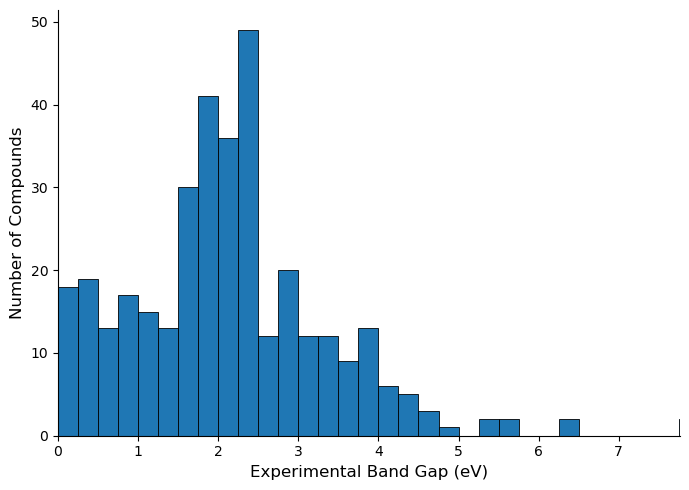

In [9]:
import matplotlib.pyplot as plt
import numpy as np
bandgaps = df_ternary["band_gap_experimenatal (eV)"].dropna()

# Bin width: 0.25 eV
bin_width = 0.25
bins = np.arange(0, bandgaps.max() + bin_width, bin_width)

# Plot
plt.figure(figsize=(7, 5))
plt.hist(bandgaps, bins=bins, edgecolor='black', linewidth=0.6)

# Axes labels
plt.xlabel("Experimental Band Gap (eV)", fontsize=12)
plt.ylabel("Number of Compounds", fontsize=12)

# Axis formatting
plt.tick_params(axis='both', labelsize=10)
plt.xlim(0, bandgaps.max())

# Remove top/right spines (journal style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig("Figure1_Experimental_BandGap_Distribution.png", dpi=300)
plt.show()

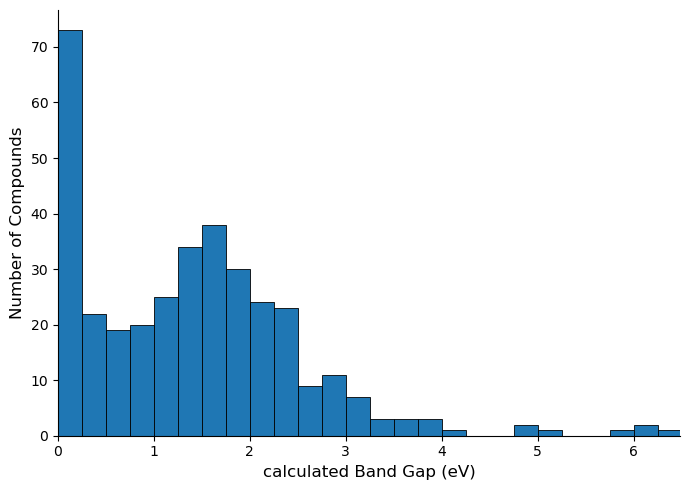

In [10]:
bandgaps = df_ternary["band_gap_calculated (eV)"].dropna()

# Bin width: 0.25 eV
bin_width = 0.25
bins = np.arange(0, bandgaps.max() + bin_width, bin_width)

# Plot
plt.figure(figsize=(7, 5))
plt.hist(bandgaps, bins=bins, edgecolor='black', linewidth=0.6)

# Axes labels
plt.xlabel("calculated Band Gap (eV)", fontsize=12)
plt.ylabel("Number of Compounds", fontsize=12)

# Axis formatting
plt.tick_params(axis='both', labelsize=10)
plt.xlim(0, bandgaps.max())

# Remove top/right spines (journal style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig("Figure1_Experimental_BandGap_Distribution.png", dpi=300)
plt.show()

## Step 5 — Composition Parsing

Each chemical formula is parsed into a normalised atomic fraction dictionary.

**Examples:**
- `GaAs` → `{Ga: 0.5, As: 0.5}`
- `BaCuTeF` → `{Ba: 0.25, Cu: 0.25, Te: 0.25, F: 0.25}`
- `Si` → `{Si: 1.0}`

**Step 5a** — Test the regex pattern on an example formula with LaTeX formatting.

In [11]:
import re
formula =  "Zr$_{7}$Fe$_{92}$B"
clean_formula = formula.replace("$","").replace("_","").replace("{","").replace("}","")
clean_formula
element_concenration_pattern = re.compile("([A-Z][a-z]?)([0-9.]*)")
elem_conc_pairs = element_concenration_pattern.findall(clean_formula)
elem_conc_pairs

[('Zr', '7'), ('Fe', '92'), ('B', '')]

**Step 5b** — Define `remove_characters()`: cleans LaTeX symbols (`$`, `_`, `{`, `}`) from formula strings.

In [12]:
def remove_characters(formula, characters_to_remove="$_{} "):
    clean_formula = formula
    for ch in characters_to_remove:
        clean_formula = clean_formula.replace(ch,"")
    return clean_formula    

**Step 5c** — Define `convert_to_composition_dict()`: converts a clean formula string into a normalised atomic fraction dictionary.

In [13]:
def convert_to_composition_dict(clean_formula):
    try:
        
        elem_conc_pairs = element_concenration_pattern.findall(clean_formula)
        
        
        comp_dict = {}
        for elem, conc_str in elem_conc_pairs:
            if conc_str=="":
                comp_dict[elem] = 1
            else:
                comp_dict[elem]=float(conc_str) 

        conc_sum = 0
        for elem, conc in comp_dict.items():
            conc_sum +=conc
        conc_sum

        for elem, conc in comp_dict.items():
            comp_dict[elem] =conc/conc_sum

        return comp_dict
    except ValueError:
        print("Error when converting: ", clean_formula)
        print("pairs:",elem_conc_pairs)
        return None

**Step 5d** — Apply both parsing functions to every row in the dataset.

In [14]:
df_ternary["clean_formula"]=df_ternary["formula"].map(remove_characters)
df_ternary["comp_dict"]=df_ternary["clean_formula"].map(convert_to_composition_dict)
df_ternary

,formula,Crystal System,band_gap_calculated (eV),band_gap_experimenatal (eV),clean_formula,comp_dict
0,LiB3O5,Orthorhombic,6.4843,7.76500,LiB3O5,"{'Li': 0.1111111111111111, 'B': 0.333333333333..."
1,LiB3O5,Orthorhombic,6.1706,7.76500,LiB3O5,"{'Li': 0.1111111111111111, 'B': 0.333333333333..."
2,NaSbF6,Cubic,6.1153,3.76000,NaSbF6,"{'Na': 0.125, 'Sb': 0.125, 'F': 0.75}"
3,DyPO4,Tetragonal,5.8933,6.38000,DyPO4,"{'Dy': 0.16666666666666666, 'P': 0.16666666666..."
4,K2ReH9,Hexagonal,5.2130,5.71000,K2ReH9,"{'K': 0.16666666666666666, 'Re': 0.08333333333..."
...,...,...,...,...,...,...
347,ZnGeAs2,Tetragonal,0.0000,1.05875,ZnGeAs2,"{'Zn': 0.25, 'Ge': 0.25, 'As': 0.5}"
348,ZnSnAs2,Tetragonal,0.0000,0.77000,ZnSnAs2,"{'Zn': 0.25, 'Sn': 0.25, 'As': 0.5}"
349,ZnSnAs2,Tetragonal,0.0000,0.77000,ZnSnAs2,"{'Zn': 0.25, 'Sn': 0.25, 'As': 0.5}"
350,ZnSnSb2,Tetragonal,0.0000,0.35000,ZnSnSb2,"{'Zn': 0.25, 'Sn': 0.25, 'Sb': 0.5}"


## Step 6 — Feature Engineering

For each of the 90 elemental properties, three composition-weighted statistics are computed for every compound, yielding **276 features** total:

| Feature Type | Formula | Column prefix |
|---|---|---|
| Weighted average | p̄ₖ = Σ wᵢ pₖ(Eᵢ) | `avg_*` |
| Max–min difference | Δpₖ = max pₖ − min pₖ | `diff_*` |
| Weighted variance | σ²ₖ = Σ wᵢ(pₖ(Eᵢ) − p̄ₖ)² | `var_*` |

The `avg_*` features capture the average elemental environment.  
The `diff_*` features capture elemental contrast (e.g., electronegativity difference).  
The `var_*` features capture chemical heterogeneity within the compound.

In [15]:
import pandas as pd
import numpy as np
import ast # Used to convert strings to dictionaries

# --- 1. SET YOUR COLUMN/DATAFRAME NAMES ---
df_ternary = df_ternary  # Your compounds (with 'comp_dict')
df= df  # Your elements (with properties)
parsed_col_name = "comp_dict" 
formula_col_name = "formula" # The column in df2 with "H", "Si", etc.

# --- 2. CLEAN DF1 (Compounds) ---
# This converts the string "{'S': 1.0}" into a real dictionary {'S': 1.0}
# and cleans the keys (e.g., "S " -> "S")
def convert_and_clean_dict(dict_string):
    try:
        comp_dict = ast.literal_eval(str(dict_string))
        if not isinstance(comp_dict, dict):
            return np.nan
        cleaned_dict = {}
        for element, fraction in comp_dict.items():
            if isinstance(element, str):
                cleaned_key = element.strip()
                cleaned_dict[cleaned_key] = fraction
            else:
                return np.nan
        return cleaned_dict
    except (ValueError, SyntaxError, TypeError):
        return np.nan

print("Cleaning df_ternary 'comp_dict' column...")
df_ternary[parsed_col_name] = df_ternary[parsed_col_name].apply(convert_and_clean_dict)
df_ternary = df_ternary.dropna(subset=[parsed_col_name]) # Drop rows that failed conversion
print("df_ternary cleaning complete.")

# --- 3. CLEAN AND SET INDEX FOR DF2 (Elements) ---
# This sets the index to the 'formula' column AND cleans it
try:
    # If 'formula' is already the index, just clean it
    if df.index.name == formula_col_name:
        df.index = df.index.astype(str).str.strip()
        print(f"df index '{formula_col_name}' was already set. Index cleaned.")
    # If 'formula' is a column, set it as the index and clean it
    elif formula_col_name in df.columns:
        df = df.set_index(formula_col_name)
        df.index = df.index.astype(str).str.strip()
        print(f"df index set to '{formula_col_name}' and cleaned.")
    else:
        # If 'formula' is not the index or a column, we have a problem.
        # This might be your case. RELOAD df2 if this error appears.
        print(f"Error: Column or Index '{formula_col_name}' not found in df.")
        print("Please RELOAD your df dataframe from its file and try again.")
        
except Exception as e:
    print(f"An error occurred setting up df: {e}")


# --- 4. HELPER FUNCTIONS (The FAST version, uses INDEX) ---

def get_weighted_avg(comp_dict, property_name, df_elements):
    total_avg = 0
    try:
        for element, fraction in comp_dict.items():
            # Uses .loc[] for fast index lookup
            prop_value = df_elements.loc[element, property_name] 
            if pd.isna(prop_value):
                return np.nan 
            total_avg += fraction * prop_value
        return total_avg
    except KeyError as e:
        # This element is truly missing from df2
        return np.nan 
    except TypeError:
        return np.nan

def get_difference(comp_dict, property_name, df_elements):
    values = []
    try:
        for element in comp_dict.keys():
            prop_value = df_elements.loc[element, property_name]
            if pd.isna(prop_value):
                return np.nan
            values.append(prop_value)
        if not values:
            return 0
        return max(values) - min(values)
    except (KeyError, AttributeError, TypeError):
        return np.nan

def get_weighted_variance(comp_dict, property_name, mean_val, df_elements):
    if pd.isna(mean_val):
        return np.nan
    total_var = 0
    try:
        for element, fraction in comp_dict.items():
            prop_value = df_elements.loc[element, property_name]
            if pd.isna(prop_value):
                return np.nan
            total_var += fraction * ((prop_value - mean_val) ** 2)
        return total_var
    except (KeyError, AttributeError, TypeError):
        return np.nan

# --- 5. MAIN FEATURE ENGINEERING LOOP ---

property_list = df.columns # Get all property columns

print(f"Starting feature engineering for {len(property_list)} properties...")

for prop in property_list:
    avg_col_name = f'avg_{prop}'
    df_ternary[avg_col_name] = df_ternary[parsed_col_name].apply(
        lambda comp: get_weighted_avg(comp, prop, df)
    )
    
    diff_col_name = f'diff_{prop}'
    df_ternary[diff_col_name] = df_ternary[parsed_col_name].apply(
        lambda comp: get_difference(comp, prop, df)
    )
    
    var_col_name = f'var_{prop}'
    df_ternary[var_col_name] = df_ternary.apply(
        lambda row: get_weighted_variance(row[parsed_col_name], prop, row[avg_col_name], df),
        axis=1
    )

print("--- Feature engineering complete! ---")

# --- 6. CHECK YOUR RESULTS ---
print("Checking for NaN values in a new feature column...")
if not property_list.empty:
    check_col = f'avg_{property_list[0]}' 
    nan_percentage = df_ternary[check_col].isna().mean() * 100
    print(f"Percentage of NaN in '{check_col}': {nan_percentage:.2f}%")

    if nan_percentage < 100:
        print("\nSuccess! Non-NaN values were calculated.")
    else:
        print("\nFailure: Still 100% NaN. Elements like 'C', 'P', 'S' may be missing from df2.")
else:
    print("Error: No property columns found in df.")

print("\nFinal df_ternary head:")
print(df_ternary.head())

Cleaning df_ternary 'comp_dict' column...
df_ternary cleaning complete.
df index 'formula' was already set. Index cleaned.
Starting feature engineering for 90 properties...


/tmp/ipykernel_2841353/3597937243.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ternary[var_col_name] = df_ternary.apply(
/tmp/ipykernel_2841353/3597937243.py:111: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ternary[avg_col_name] = df_ternary[parsed_col_name].apply(
/tmp/ipykernel_2841353/3597937243.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) i

--- Feature engineering complete! ---
Checking for NaN values in a new feature column...
Percentage of NaN in 'avg_atomic_number': 0.00%

Success! Non-NaN values were calculated.

Final df_ternary head:
  formula Crystal System  band_gap_calculated (eV)  \
0  LiB3O5   Orthorhombic                    6.4843   
1  LiB3O5   Orthorhombic                    6.1706   
2  NaSbF6          Cubic                    6.1153   
3   DyPO4     Tetragonal                    5.8933   
4  K2ReH9      Hexagonal                    5.2130   

   band_gap_experimenatal (eV) clean_formula  \
0                        7.765        LiB3O5   
1                        7.765        LiB3O5   
2                        3.760        NaSbF6   
3                        6.380         DyPO4   
4                        5.710        K2ReH9   

                                           comp_dict  avg_atomic_number  \
0  {'Li': 0.1111111111111111, 'B': 0.333333333333...           6.444444   
1  {'Li': 0.1111111111111111, 'B'

In [16]:
df_ternary

,formula,Crystal System,band_gap_calculated (eV),band_gap_experimenatal (eV),clean_formula,comp_dict,avg_atomic_number,diff_atomic_number,var_atomic_number,avg_periodic_number_bottom_up,...,var_delta_h_interface_o_in_m_miedema,avg_delta_h_interface_m_in_o_miedema,diff_delta_h_interface_m_in_o_miedema,var_delta_h_interface_m_in_o_miedema,avg_delta_h_interface_m_in_s_miedema,diff_delta_h_interface_m_in_s_miedema,var_delta_h_interface_m_in_s_miedema,avg_oxidation_state_first,diff_oxidation_state_first,var_oxidation_state_first
0,LiB3O5,Orthorhombic,6.4843,7.76500,LiB3O5,"{'Li': 0.1111111111111111, 'B': 0.333333333333...",6.444444,5.0,3.358025,97.444444,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,5.0,5.333333
1,LiB3O5,Orthorhombic,6.1706,7.76500,LiB3O5,"{'Li': 0.1111111111111111, 'B': 0.333333333333...",6.444444,5.0,3.358025,97.444444,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,5.0,5.333333
2,NaSbF6,Cubic,6.1153,3.76000,NaSbF6,"{'Na': 0.125, 'Sb': 0.125, 'F': 0.75}",14.500000,42.0,190.750000,93.750000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.25,4.0,1.937500
3,DyPO4,Tetragonal,5.8933,6.38000,DyPO4,"{'Dy': 0.16666666666666666, 'P': 0.16666666666...",18.833333,58.0,451.472222,85.833333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.50,5.0,4.583333
4,K2ReH9,Hexagonal,5.2130,5.71000,K2ReH9,"{'K': 0.16666666666666666, 'Re': 0.08333333333...",10.166667,74.0,426.305556,91.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.25,3.0,0.687500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,ZnGeAs2,Tetragonal,0.0000,1.05875,ZnGeAs2,"{'Zn': 0.25, 'Ge': 0.25, 'As': 0.5}",32.000000,3.0,1.500000,81.000000,...,2970.75,-462.50,232.0,6730.2500,-132.00,123.0,2713.5000,2.50,1.0,0.250000
348,ZnSnAs2,Tetragonal,0.0000,0.77000,ZnSnAs2,"{'Zn': 0.25, 'Sn': 0.25, 'As': 0.5}",36.500000,20.0,62.250000,76.500000,...,2970.75,-462.75,233.0,6789.1875,-131.25,123.0,2679.1875,2.50,1.0,0.250000
349,ZnSnAs2,Tetragonal,0.0000,0.77000,ZnSnAs2,"{'Zn': 0.25, 'Sn': 0.25, 'As': 0.5}",36.500000,20.0,62.250000,76.500000,...,2970.75,-462.75,233.0,6789.1875,-131.25,123.0,2679.1875,2.50,1.0,0.250000
350,ZnSnSb2,Tetragonal,0.0000,0.35000,ZnSnSb2,"{'Zn': 0.25, 'Sn': 0.25, 'Sb': 0.5}",45.500000,21.0,80.250000,67.500000,...,2060.75,-475.25,233.0,6901.6875,-141.25,103.0,1814.1875,2.50,1.0,0.250000


In [17]:
df_ternary.to_csv("my_file.csv", index=False)


/tmp/ipykernel_2841353/1350514920.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


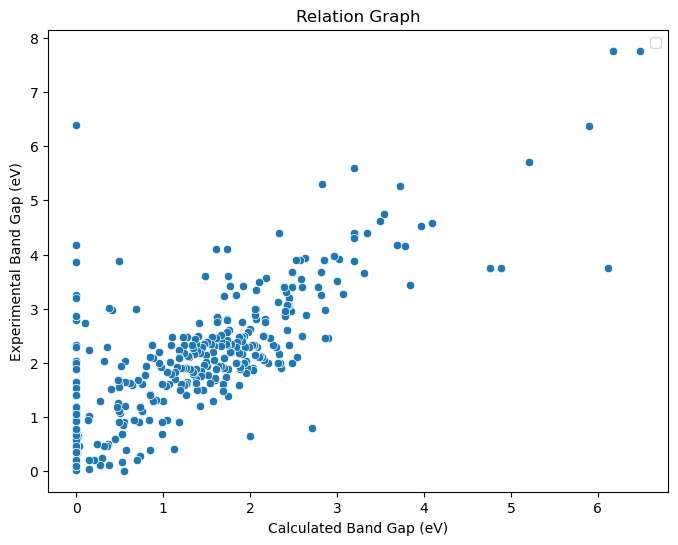

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df_final' is your clean dataframe
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_ternary, x='band_gap_calculated (eV)', y='band_gap_experimenatal (eV)')


plt.xlabel('Calculated Band Gap (eV)')
plt.ylabel('Experimental Band Gap (eV)')
plt.title('Relation Graph')
plt.legend()
plt.show()

## Step 7 — Data Preparation & Train/Test Split

Before training:
- Target variable: `band_gap_experimenatal (eV)` (experimental band gap)
- Features: 276 CBFV descriptors + `band_gap_calculated (eV)` (DFT baseline as a feature)
- Infinite and missing values replaced with column means (`SimpleImputer`)
- **80/20 train/test split** (`random_state=42`) — 20% is held out and never used during CV
- 10-Fold Cross-Validation is applied **only within the training set** to avoid data leakage

---

## Step 8 — Model Benchmarking (10-Fold Cross-Validation)

All 12 regression algorithms are evaluated with **identical 10-Fold CV splits** for fair comparison.  
Models are grouped by type:

**8a — XGBoost (Gradient Boosted Trees)**  
Optimised gradient boosting with histogram-based splits. Testing multiple `n_estimators` and `max_depth` configurations.

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# --- 1. Define Your Features (X) and Target (y) ---

# Your target (Y) is the experimental bandgap
target_col = 'band_gap_experimenatal (eV)' 

# Your features (X) are all the columns you engineered,
# PLUS the 'band_gap_calculated'
# We must exclude non-numeric or leaky columns.

# First, drop any rows where your target is missing
df_ternary_cleaned = df_ternary.dropna(subset=[target_col])

# Get a list of all your new feature columns
feature_cols = [col for col in df_ternary_cleaned.columns if col.startswith(('avg_', 'diff_', 'var_'))]

# Don't forget your most important feature!
feature_cols.append('band_gap_calculated (eV)') 

# Create X and y
X = df_ternary_cleaned[feature_cols]
y = df_ternary_cleaned[target_col]

print(f"Using {len(feature_cols)} features.")
print(f"Training on {X.shape[0]} samples.")

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# --- 2. Handle Missing, Infinite, and Extreme Values (FIXED) ---

print("Starting Step 2: Cleaning features...")

# First, replace all infinite values (positive and negative) with NaN
# This is the critical line.
X = X.replace([np.inf, -np.inf], np.nan)
print("Replaced 'inf' values with 'nan'.")

cols_all_nan = X.columns[X.isna().all()]
X = X.drop(columns=cols_all_nan)
print("Dropped all-NaN columns:", list(cols_all_nan))

# Now, the imputer will fill both NaNs (from missing elements)
# and NaNs (that were 'inf') with the column mean.
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
print("Imputed 'nan' values with column means.")

# Convert back to DataFrame
X = pd.DataFrame(X_imputed, columns=X.columns)

# --- !! NEW SAFETY CHECK !! ---
# This fixes the "...or a value too large for dtype('float32')" part.

# Get the maximum and minimum values a float32 can hold
finfo = np.finfo(np.float32)

# 1. Replace any 'inf' values that the imputer might have created
X = X.replace([np.inf, -np.inf], np.nan) 

# 2. Clip all values to be within the valid float32 range
X = X.clip(finfo.min, finfo.max)

# 3. Fill any remaining NaNs (if a whole column was bad) with 0
X = X.fillna(0)
print("Clipped extreme values and filled any final NaNs.")


# --- 3. Split Data into Training and Testing Sets ---
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np

X_train_arr = np.array(X_train)
y_train_arr = np.array(y_train)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

model = XGBRegressor(tree_method='hist', n_estimators=100, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", root_mean_squared_error(y_true, y_pred))

Using 271 features.
Training on 352 samples.
Starting Step 2: Cleaning features...
Replaced 'inf' values with 'nan'.
Dropped all-NaN columns: ['avg_bulk_modulus', 'diff_bulk_modulus', 'var_bulk_modulus']
Imputed 'nan' values with column means.
Clipped extreme values and filled any final NaNs.
Training set size: 281
Testing set size: 71
R2: 0.7977308632971429
MAE: 0.35845191477561433
RMSE: 0.5605333779970841


In [20]:
model = XGBRegressor(tree_method='hist', n_estimators=200, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.799699536057475
MAE: 0.35320425975798425
RMSE: 0.5577988900568829


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [21]:
model = XGBRegressor(tree_method='hist', n_estimators=300, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7997622395254725
MAE: 0.35275164551368526
RMSE: 0.5577115745762563


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [22]:
model = XGBRegressor(tree_method='hist', n_estimators=50, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7969890666218056
MAE: 0.37089748194075445
RMSE: 0.5615602802600996


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [23]:
model = XGBRegressor(tree_method='hist', n_estimators=25, max_depth=3, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.798051459332981
MAE: 0.3857978252461891
RMSE: 0.5600889798890563


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [24]:
model = XGBRegressor(tree_method='hist', n_estimators=25, max_depth=5, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7802930523122397
MAE: 0.37128021243859993
RMSE: 0.5841959790421949


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8b — Random Forest**  
Ensemble of decision trees trained with bootstrap sampling. Testing multiple `n_estimators` configurations.

In [25]:
model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7867864912716304
MAE: 0.40074548008176775
RMSE: 0.5754982756561545


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [26]:
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7845329315523863
MAE: 0.40274182697680316
RMSE: 0.5785316453156323


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [27]:
model = RandomForestRegressor(n_estimators=100, random_state=21, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7983676912448975
MAE: 0.39302001817878507
RMSE: 0.5596502854569654


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [28]:
model = RandomForestRegressor(n_estimators=50, random_state=21, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7892275435180084
MAE: 0.401925836635272
RMSE: 0.5721943915537814


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8c — Gradient Boosting (sklearn)**  
Sequential tree boosting that corrects residuals. Testing multiple `n_estimators` and `max_depth` combinations.

In [29]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.8164934549641822
MAE: 0.35315651908865986
RMSE: 0.5339031060723068


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [30]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.807548226258022
MAE: 0.3424907543936242
RMSE: 0.5467611234602684


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [31]:
model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=3)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.8151090104813069
MAE: 0.3387085315567814
RMSE: 0.5359133077188483


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [32]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7925416522370096
MAE: 0.3513868460532032
RMSE: 0.5676780807466182


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8d — Linear & Regularized Models**  
Interpretable baselines: Linear Regression and Ridge Regression (L2 regularisation). These models assume a linear relationship between features and band gap.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LinearRegression()
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.24065862993897058
MAE: 0.8069143336937941
RMSE: 1.0860634513923662


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [34]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = Ridge(alpha=1.0)  # alpha = regularization strength

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))   

R2: 0.6488329818284229
MAE: 0.4846508986189322
RMSE: 0.7346758499532197


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [35]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = Ridge(alpha=2.0)  # alpha = regularization strength

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))   

R2:

/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


 0.680818541753113
MAE: 0.4722508222290544
RMSE: 0.7004186982166052


**8e — Support Vector Regression (SVR)**  
RBF kernel SVR constructs a flexible nonlinear regression function. Requires feature standardisation.

In [36]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.6318451747104669
MAE: 0.4498868056997379
RMSE: 0.7522360673129113


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8f — k-Nearest Neighbors (k-NN)**  
Predicts using the weighted average of the k closest compounds in feature space. Testing k = 5, 10, 15.

In [37]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KNeighborsRegressor(n_neighbors=5)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.6106004904149238
MAE: 0.5342532070460227
RMSE: 0.773635881419084


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [38]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KNeighborsRegressor(n_neighbors=10)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.4827429702590248
MAE: 0.6112419173951704
RMSE: 0.8916452594346732


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [39]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KNeighborsRegressor(n_neighbors=15)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.45226327942151245
MAE: 0.6543930335835227
RMSE: 0.9175396332457086


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8g — Bayesian Ridge Regression**  
Uses Gaussian priors on coefficients for uncertainty-aware predictions and automatic regularisation.

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = BayesianRidge()
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7212732145711798
MAE: 0.46269435962364275
RMSE: 0.6545280410236229


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8h — MLP Neural Network**  
Multi-layer perceptron with two hidden layers (100, 50 neurons) and ReLU activation. Captures highly nonlinear relationships.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import KFold
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np



y_true, y_pred = [], []

model = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=1500, random_state=42, learning_rate_init=0.001)

for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7891474682464252
MAE: 0.3424026728381237
RMSE: 0.5692831298874582


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [42]:


model = MLPRegressor(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42, learning_rate_init=0.001)
y_true, y_pred = [], []
for train_index, test_index in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.7891474682464252
MAE: 0.3424026728381237
RMSE: 0.5692831298874582


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8i — Extra Trees Regressor** ⭐ *Best Model*  
Similar to Random Forest but uses **random thresholds** instead of optimal splits — faster training, often better generalisation.  
**This is the best-performing model for ternary compounds compounds: ExtraTrees (n_estimators=300) → R² = 0.8397, MAE = 0.3150 eV**

In [43]:
from sklearn.ensemble import ExtraTreesRegressor

# Model
model = ExtraTreesRegressor(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.8372267757242013
MAE: 0.31952840222922924
RMSE: 0.502838070520238


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [44]:
from sklearn.ensemble import ExtraTreesRegressor

# Model
model = ExtraTreesRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.8385798076185225
MAE: 0.31555596633291844
RMSE: 0.5007438203747453


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [45]:
from sklearn.ensemble import ExtraTreesRegressor

# Model
model = ExtraTreesRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.8397489823756317
MAE: 0.3150220684151168
RMSE: 0.498927068063599


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Step 9 — Feature Importance Analysis

Feature importances from the trained Extra Trees model show which physical descriptors drive predictions.  
The dominant feature (`var_oxidation_state_first`) encodes **ionicity** — greater oxidation state variance → stronger cation–anion interactions → wider band gap.  
Mendeleev number differences encode electronegativity and atomic radius contrasts.

X columns: 268
Feature names: 268
MATCH! Generating plot...


/tmp/ipykernel_2841353/1003180243.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')


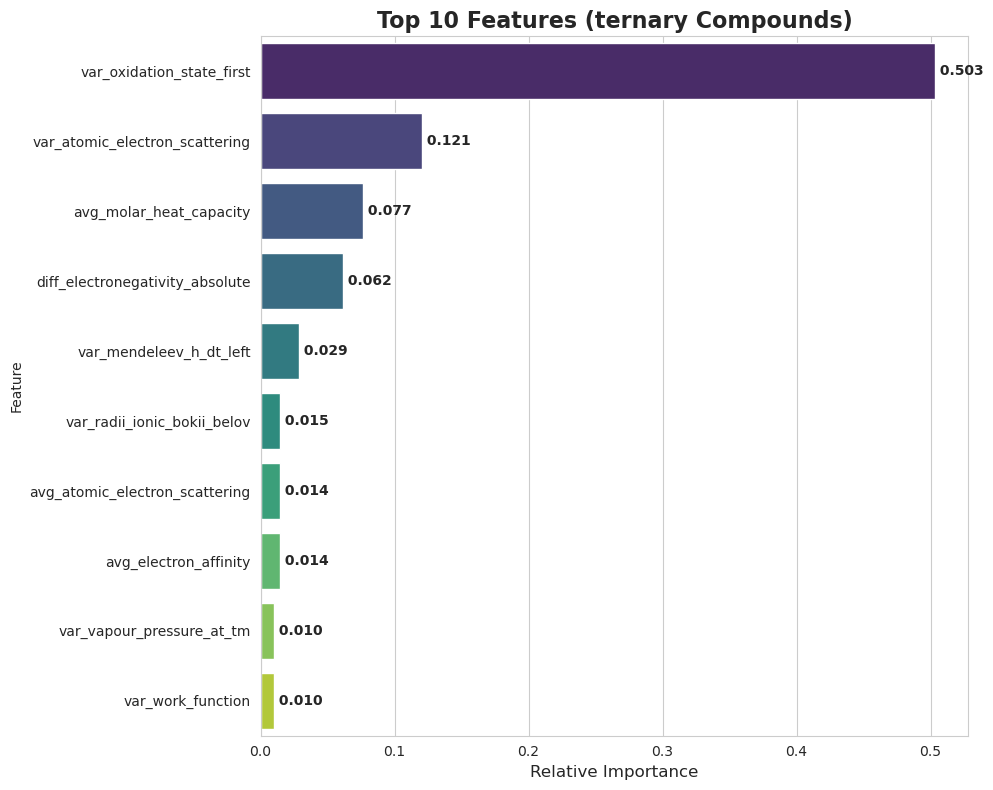

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. CORRECTED LIST (Removed 'band_gap_calculated (eV)') ---
# We ONLY exclude the text columns and the TARGET (Experimental Gap).
# We KEEP 'band_gap_calculated (eV)' because it is a feature in X.
non_features = ['formula', 'band_gap_experimenatal (eV)', 'avg_delta_h_interface_m_in_s_miedema', 'diff_delta_h_interface_m_in_o_miedema',	'diff_delta_h_interface_m_in_s_miedema',
                'Crystal System', 'clean_formula', 'comp_dict']

# Get the feature names
feature_names = [col for col in df_ternary_cleaned.columns if col not in non_features]

# --- 2. VERIFY ALIGNMENT ---
print(f"X columns: {X.shape[1]}")
print(f"Feature names: {len(feature_names)}")

if X.shape[1] == len(feature_names):
    print("MATCH! Generating plot...")
    
    # --- 3. TRAIN AND PLOT ---
    model.fit(X, y)
    importances = model.feature_importances_

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Sort
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    # Plot Top 10
    plt.figure(figsize=(10, 8))
    sns.set_style("whitegrid")
    
    top_10 = feature_importance_df.head(10)
    sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')

    plt.title('Top 10 Features (ternary Compounds)', fontsize=16, fontweight='bold')
    plt.xlabel('Relative Importance', fontsize=12)
    
    # Add values
    for index, value in enumerate(top_10['Importance']):
        plt.text(value, index, f' {value:.3f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('ternary 10 feature', dpi=300)
    plt.show()
    
else:
    print("\nSTILL MISMATCHED!")
    print("Trying to find the missing column...")
    # Helper to find what is extra
    all_cols = set(df_ternary_cleaned.columns)
    kept_cols = set(feature_names)
    dropped = all_cols - kept_cols
    print(f"Columns currently excluded: {dropped}")
    print("Check if one of these is actually inside your X variable.")

## Step 10 — Parity Plot: Predicted vs. Experimental Band Gap

Scatter plot of out-of-fold CV predictions against experimental values.  
Points close to the red dashed diagonal (y = x) indicate accurate predictions.  
The model is most precise in the 0–3 eV range (common semiconductors); some scatter appears for wide-gap insulators (> 4 eV).

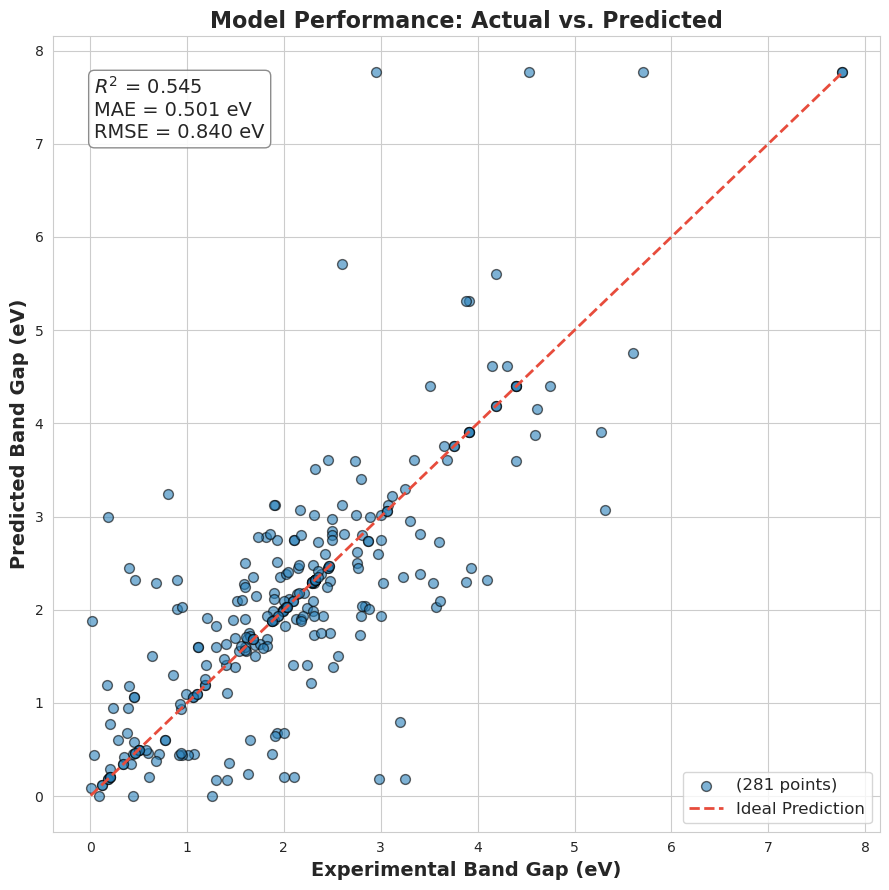

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# --- 1. PREPARE DATA ---
# Convert your lists to numpy arrays (easiest for plotting)
actual_values = np.array(y_true)
predicted_values = np.array(y_pred)

# Optional: Fix any negative predictions to 0.0 (Physics fix)
predicted_values = np.maximum(predicted_values, 0.0)

# --- 2. CALCULATE METRICS (For the label) ---
r2 = r2_score(actual_values, predicted_values)
mae = mean_absolute_error(actual_values, predicted_values)
rmse = root_mean_squared_error(actual_values, predicted_values)

# --- 3. GENERATE THE PLOT ---
plt.figure(figsize=(9, 9))
sns.set_style("whitegrid")

# The Scatter Plot
plt.scatter(actual_values, predicted_values, 
            alpha=0.6, 
            color='#2980b9', 
            edgecolor='k', 
            s=50, 
            label=f'({len(actual_values)} points)')

# The "Perfect Prediction" Red Dashed Line (y=x)
min_val = min(actual_values.min(), predicted_values.min())
max_val = max(actual_values.max(), predicted_values.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#e74c3c', 
         linestyle='--', 
         linewidth=2, 
         label='Ideal Prediction')

# --- 4. LABELS AND BOX ---
plt.xlabel('Experimental Band Gap (eV)', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Band Gap (eV)', fontsize=14, fontweight='bold')
plt.title('Model Performance: Actual vs. Predicted', fontsize=16, fontweight='bold')

# Add the Score Box
text_str = f'$R^2$ = {r2:.3f}\nMAE = {mae:.3f} eV\nRMSE = {rmse:.3f} eV'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=props)

plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()

# Save and Show
plt.savefig('ternary_exp vs predicted.png', dpi=300)
plt.show()

## Step 11 — Monte Carlo Cross-Validation (Robustness Test)

To confirm that the CV performance is not a result of a lucky random split, the best model is evaluated 20 times with different random partitions.  
Each iteration holds out **10 random samples** as a blind validation set.  
If MAE stays stable across all 20 runs, it confirms the model captures genuine physical trends.

In [48]:
from sklearn.model_selection import ShuffleSplit

# --- 1. SETUP THE REPEATED TEST ---
# n_splits=50  -> We will do this test 20 times
# test_size=10 -> Every time, we pick exactly 10 random points for testing
ss = ShuffleSplit(n_splits=20, test_size=10, random_state=42)

# Lists to save the score of each round
scores_r2 = []
scores_mae = []
scores_rmse = []

# Convert to numpy arrays (safer for splitting)
X_arr = np.array(X)
y_arr = np.array(y)

model = ExtraTreesRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)

print("Starting Repeated 10-Point Testing (20 Rounds)...")

# --- 2. THE LOOP ---
for train_index, test_index in ss.split(X_arr):
    
    # Create the split for this specific round
    X_train, X_test = X_arr[train_index], X_arr[test_index]
    y_train, y_test = y_arr[train_index], y_arr[test_index]
    
    # Train
    model.fit(X_train, y_train)
    
    # Test
    y_pred = model.predict(X_test)
    
    # Calculate Scores for this round and save them
    scores_r2.append(r2_score(y_test, y_pred))
    scores_mae.append(mean_absolute_error(y_test, y_pred))
    scores_rmse.append(mean_squared_error(y_test, y_pred, squared=False))

# --- 3. FINAL RESULTS (AVERAGE) ---
print("\n--- FINAL ROBUST RESULTS (Average of 20 runs) ---")
print(f"Average R2:   {np.mean(scores_r2):.4f}")
print(f"Average MAE:  {np.mean(scores_mae):.4f}")
print(f"Average RMSE: {np.mean(scores_rmse):.4f}")

Starting Repeated 10-Point Testing (20 Rounds)...


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6


--- FINAL ROBUST RESULTS (Average of 20 runs) ---
Average R2:   0.7110
Average MAE:  0.3506
Average RMSE: 0.5590


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Step 12 — Leave-One-Group-Out Validation (Generalization Test)

The strictest test: the model is trained on all compounds **except** those containing a specific element family, then evaluated on that completely unseen family.  
This simulates a real materials discovery scenario — predicting properties of new, unknown chemical systems.  
Sub-eV MAE here means the model has learned transferable physical principles (electronegativity, ionicity), not formula memorisation.

In [49]:
from sklearn.model_selection import LeaveOneGroupOut


# --- 3. Find the "Compound Element" for Grouping ---
# This finds the last element in the formula (e.g. 'BaZn2As2' -> 'As')
def get_main_element(formula):
    elements = re.findall(r'[A-Z][a-z]*', str(formula))
    return elements[-1] if elements else 'Unknown'

groups = df_ternary_cleaned['formula'].apply(get_main_element).values

# --- 4. The Professor's Test: Train on Mixed, Test on Unseen Element ---
X_arr = np.array(X)
y_arr = np.array(y)

# LeaveOneGroupOut splits the data by the Compound Element automatically
logo = LeaveOneGroupOut()
model = ExtraTreesRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)

y_true, y_pred = [], []

print("Starting Testing (Training on mixed, testing on unseen elements)...\n")

for train_index, test_index in logo.split(X_arr, y_arr, groups):

    test_element = groups[test_index[-1]]
    
    # We skip elements that only have 1 or 2 rows (too small to reliably test)
    if len(test_index) < 3:
        continue

        # ==========================================
    # --- THE "SPY BLOCK" (See what it's doing) ---
    # ==========================================
    print(f"\n--- ROUND: Hidden Element is [{test_element}] ---")
    
    # Find the actual chemical formulas going into the TEST set
    test_formulas = df_ternary_cleaned.iloc[test_index]['formula'].unique()
    print(f"TESTING on {len(test_index)} compounds. Examples: {test_formulas[:5]}") 
    
    # Check what elements are in the TRAIN set to prove the test_element is missing
    train_elements = np.unique(groups[train_index])
    is_leaking = test_element in train_elements
    print(f"TRAINING on {len(train_index)} compounds.")
    print(f"Is '{test_element}' hiding in the Training set? {'Yes (ERROR!)' if is_leaking else 'No (Perfect!)'}")
    # ==========================================
        
    # Train the model
    model.fit(X_arr[train_index], y_arr[train_index])
    
    # Predict on the unseen element group
    predictions = model.predict(X_arr[test_index])
    
    # Save results
    y_true.extend(y_arr[test_index])
    y_pred.extend(predictions)

# --- 5. Print Final Results ---
print("--- FINAL RESULT ON UNSEEN ELEMENTS ---")
print("Total R2:   ", r2_score(y_true, y_pred))
print("Total MAE:  ", mean_absolute_error(y_true, y_pred))
print("Total RMSE: ", mean_squared_error(y_true, y_pred, squared=False))

Starting Testing (Training on mixed, testing on unseen elements)...


--- ROUND: Hidden Element is [As] ---
TESTING on 12 compounds. Examples: ['ZnSiAs2' 'Ca2CdAs2' 'CdSiAs2' 'Sr2Zn2As3' 'CdGeAs2']
TRAINING on 340 compounds.
Is 'As' hiding in the Training set? No (Perfect!)

--- ROUND: Hidden Element is [Br] ---
TESTING on 17 compounds. Examples: ['Rb3Bi2Br9' 'Cs3Bi2Br9' 'K2TeBr6' 'Tl2TeBr6' 'Sr2P7Br']
TRAINING on 335 compounds.
Is 'Br' hiding in the Training set? No (Perfect!)

--- ROUND: Hidden Element is [Cl] ---
TESTING on 8 compounds. Examples: ['HgBrCl' 'Cs3Sb2Cl9' 'BiSCl' 'Cd4P2Cl3' 'TlCuCl3']
TRAINING on 344 compounds.
Is 'Cl' hiding in the Training set? No (Perfect!)

--- ROUND: Hidden Element is [F] ---
TESTING on 4 compounds. Examples: ['NaSbF6' 'KTi2F7']
TRAINING on 348 compounds.
Is 'F' hiding in the Training set? No (Perfect!)

--- ROUND: Hidden Element is [Ge] ---
TESTING on 4 compounds. Examples: ['Li2CdGe' 'Li2HgGe' 'Li2ZnGe']
TRAINING on 348 compounds.
Is 'Ge' hiding 

/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8j — CatBoost**  
Gradient boosting optimised for categorical features. Uses ordered boosting to mitigate overfitting. Testing multiple `n_estimators` and `depth` configurations.

In [50]:
from catboost import CatBoostRegressor

# Model
model = CatBoostRegressor(n_estimators=200, learning_rate=0.1, depth=5, verbose=0, random_state=42)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.8174103595020549
MAE: 0.34863883593839057
RMSE: 0.5325675918078956


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [54]:
from catboost import CatBoostRegressor

# Model
model = CatBoostRegressor(n_estimators=300, learning_rate=0.1, depth=5, verbose=0, random_state=42)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.8193611203438682
MAE: 0.33892616652047747
RMSE: 0.5297150153429253


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [55]:
from catboost import CatBoostRegressor

# Model
model = CatBoostRegressor(n_estimators=100, learning_rate=0.1, depth=5, verbose=0, random_state=42)

y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.8031689689223426
MAE: 0.38044613593544574
RMSE: 0.5529469308993363


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**8k — Decision Tree**  
Single tree with recursive splits. Interpretable but prone to overfitting. Testing multiple `max_depth` values.

In [56]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=6, random_state=42)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.5425357439565165
MAE: 0.5614038696982835
RMSE: 0.8429760796037282


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [57]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=3, random_state=42)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.5264211644512081
MAE: 0.6339324874224272
RMSE: 0.8576948666311416


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [58]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=10, random_state=42)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.5204008553804882
MAE: 0.5137971751475664
RMSE: 0.8631293169537848


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [59]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=15, random_state=42)
y_true, y_pred = [], []

for train_index, test_index in kf.split(X_train_arr):
    model.fit(X_train_arr[train_index], y_train_arr[train_index])
    predictions = model.predict(X_train_arr[test_index])
    y_true.extend(y_train_arr[test_index])
    y_pred.extend(predictions)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", mean_squared_error(y_true, y_pred, squared=False))

R2: 0.5452656256539644
MAE: 0.5010375571933571
RMSE: 0.8404571195792138


/home/akash.vaghela/.local/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
